# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())   

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.
고객 규모는 6000명이고 나이는 18세부터 78세까지 분포해있으며 월 방문횟수의 최대치는 34회이고 평균 적용할인율은 0~0.5사이에 분포한다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

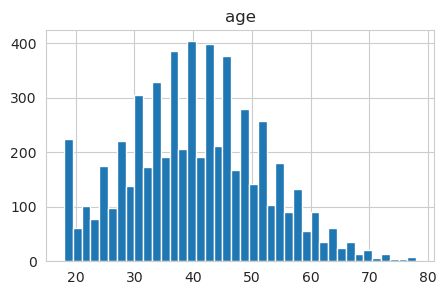

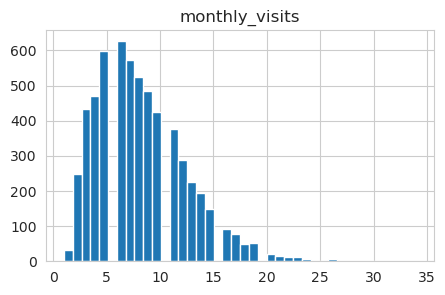

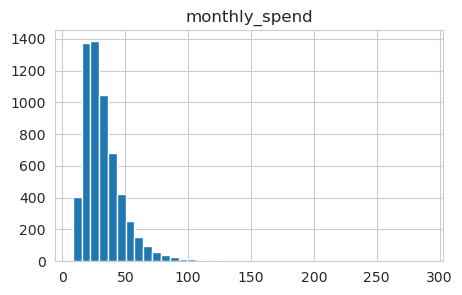

왜도 = 2.5456526289788064


/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


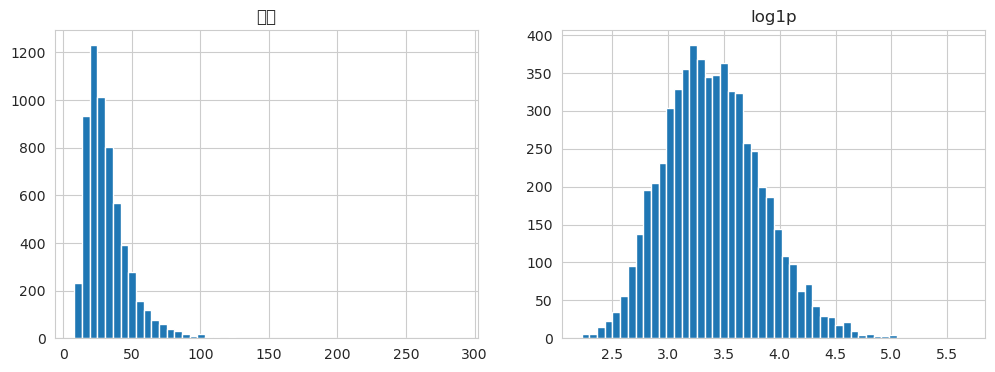

In [3]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.
소비금액이 높지 않은 고객이 대부분이기때문에 분포가 왼쪽으로 치우쳐져 있다. 
로그변환을 통해 한쪽으로 편향된 데이터를 정규분포에 가깝게 만들어준다. 

**3. 채널·등급별 매출 Boxplot**

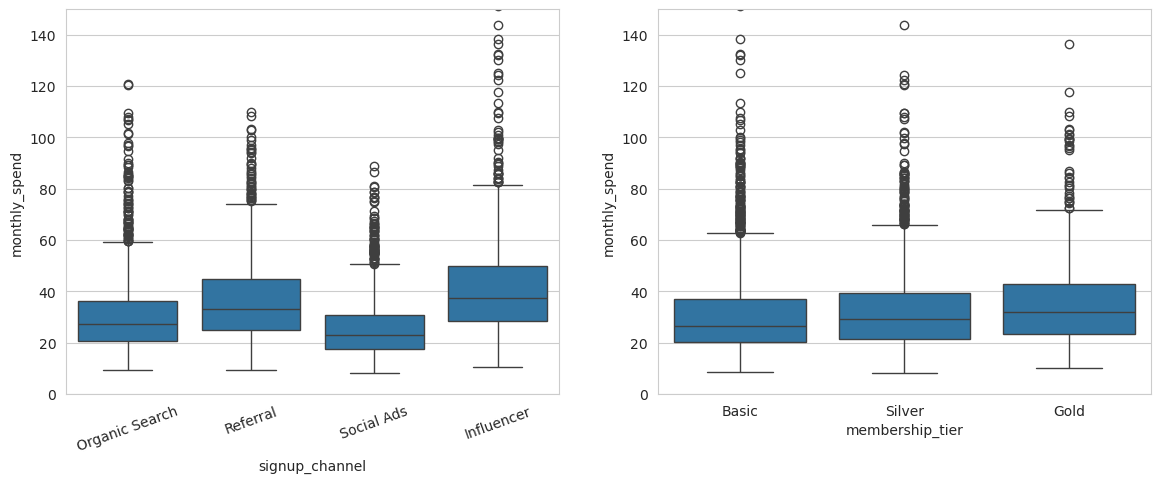

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.
Influencer 채널이 상자의 중앙값이 가장 높고 100을 넘어서는 고가치 고객이 많이 분포하고 있기 때문에 가장 고가치 채널로 보인다.
Gold 등급이 중앙값이 가장 높고 25%지점도 가장 높기 때문에 고가치 등급으로 보인다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.
1종 오류는 쿠폰 캠페인이 실제로는 효과가 없는데 효과가 있다고 판단하게 되는 오류이다. 이는 효과가 없는 캠페인을 진행하게 만들어 회사에 큰 금전적 손실을 줄 수 있다.
2종 오류는 쿠폰 캠페인이 실제로는 효과가 있는데 효과가 없다고 판단하게 되는 오류이다. 이는 캠페인을 진행하며 효과를 얻을 수 있는 기회를 놓치게 되는 손실을 끼친다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

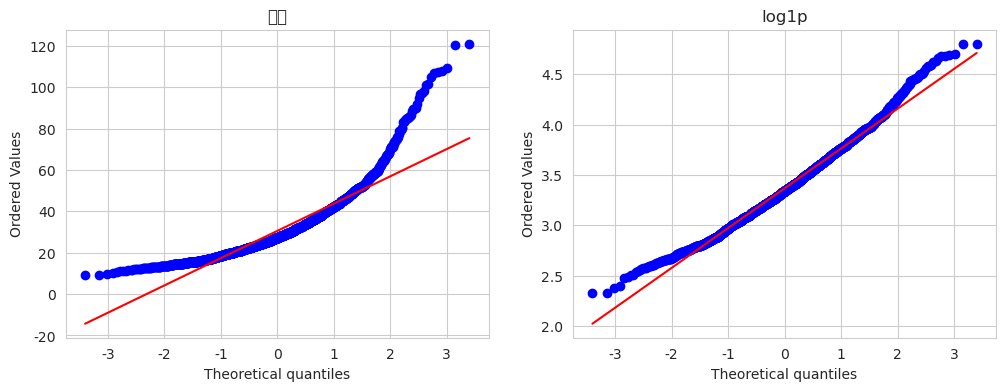

원본   ShapiroResult(statistic=0.8534534573554993, pvalue=3.6316472182249204e-21)
log1p  ShapiroResult(statistic=0.9873237609863281, pvalue=0.0002449920866638422)


In [10]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.
가설
H0: 'Organic Search'의 'monthly spend'가 정규분포를 따른다.
H1: 'Organic Search'의 'monthly spend'가 정규분포를 따르지 않는다.

-> 원본 데이터는 p-value값이 0.05보다 작으므로 귀무가설을 기각한다. 로그변환 데이터도 p-value값이 0.05보다 작으므로 귀무가설을 기각한다. 즉, 원본 데이터와 로그변환 데이터 모두 정규분포를 따르지 않는다고 해석할 수 있다. (그래도 Q-Q plot을 통해 로그변환이 효과가 있긴 했음을 확인할 수 있다.)

**6. 등분산성 검정**

In [5]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.
p값이 0.05보다 낮으므로 4개 유입채널 간의 분산이 등분산성을 만족한다고 볼 수 없다. 이러한 경우에 ANOVA를 진행하면 1종오류 가능성이 커지기 때문에 등분산 가정이 필요없는 분석법으로 진행해야한다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [6]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group =='treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.164492092129461e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.
가설
H0: 쿠폰 캠페인 유무에 따른 고객들의 monthly_spend 평균은 차이가 없다.
H1: 쿠폰 캠페인 유무에 따른 고객들의 monthly_spend 평균은 유의한 차이가 있다.
Levene 검정 결과 등분산 가정이 기각되었으므로 Welch's t-test 결과를 바탕으로 해석한다.
대조군의 평균 지출액은 약 29.71이고 실험군은 약 34.80이다. 그리고 Welch's t-test 검정 결과
p-value가 유의수준보다 작으므로 귀무가설을 기각한다. 따라서 쿠폰 캠페인 유무에 따른 고객들의 monthly_spend 평균은 유의한 차이가 있다고 해석할 수 있으므로 캠페인 지속 비용이 너무 많지만 않다면 캠페인을 지속한다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [14]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.
가설
H0: 'signup_channel'간 'monthly_spend' 평균이 차이가 없다.
H1:  'signup_channel'간 'monthly_spend' 평균에는 유의미한 차이가 있다.

-> p-value가 유의수준 0.05보다 작으므로 H0를 기각.

'Social Ads'가 다른 모든 채널보다 mean이 크므로 고가치 채널이라고 볼 수 있다.
'Influencer'가 다른 모든 채널보다 mean이 작으므로 저가치 채널이라고 볼 수 있다. 

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [17]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.
유입채널의 주효과: p-value가 유의수준 0.05보다 작으므로 고객이 어떤 채널로 유입되었는가에 따라 월별 지출액에 분명한 차이가 존재

쿠폰 캠페인의 주효과: p-value가 유의수준 0.05보다 작으므로 캠페인 진행 여부만으로도 지출액의 차이를 만들어냄

교호작용: p-value가 유의수준 0.05보다 작으므로 채널과 캠페인 간의 교호작용이 존재한다. 즉, 쿠폰 캠페인의 효과는 유입 채널마다 통계적으로 유의미하게 다르다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [19]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.05390927563052972


In [20]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        16:45:26   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?
1. `monthly_visits` → `monthly_spend` 단순선형회귀를 적합하고 회귀계수·R²을 해석하시오.

-> 회귀계수는 0.9268이고 결정계수는 0.0539이다. 이는 고객의 월간 방문 횟수가 1회 증가할 때마다 월별 지출액이 평균적으로 0.9268증가한다는 말이고 montly_visits가 montly_spend 변동의 약 5.39%를 설명한다는 의미이다.

2. 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가?

-> 세 변수 모두 p-value가 0.05보다 작으므로 모두 매출에 실제로 기여한다고 할 수 있다. 특히 'online_ad_cost'와 monthly_visits는 강력한 양의 레버이다.
할인율의 계수가 +11.42로 매우 큰 값을 가지므로 좋은 전략처럼 보이지만 할인율은 10퍼센트를 올렸을 때 1.14를 올리는 데에 반해 광고비는 1 투자할 때 0.37을 얻는 것이기에 확실한 추가 지출액 매출이다. 따라서 할인 확대보다는 고객의 방문횟수를 늘리고 광고를 효율화하는 것이 더 좋은 전략이다.

3. R²·Adjusted R²을 단순회귀와 비교하시오.
단순회귀에 비해 다중회귀 모델에서 Adj.R^2이 0.0538에서 0.2168로 4배 가량 상승했다. 독립변수가 추가되면 R^2이 무조건 커지는 경향이 있어 이를 보정한 것이 Adj.R^2인데도 4배나 증가한 것을 보면 다양한 변수를 동시에 고려하는 다중회귀 모델이 단순회귀모델보다 더 설명력이 높은 우수한 모델임을 의미한다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [22]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost','total_ad_cost']] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.211596
1   monthly_visits  1.000019
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


/usr/lib/python3/dist-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.
online_ad_cost, offline_ad_cost, total_ad_cost 세 변수의 VIF 지수가 inf로 심각하게 높은 수치이다. 이러한 수치가 나오는 이유는 total=online+offline으로 완벽한 선형관계가 있으므로 완전 다중공선성이다. 따라서 VIF의 분모가 0에 가까워서 무한대가 된다. 이를 해결하려면 두 변수와 선형관계를 가진 total_ad_cost를 제외하고 다시 VIF를 계산하면 된다.



**12. 잔차 진단** (+ 로그변환 비교)

/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 5276

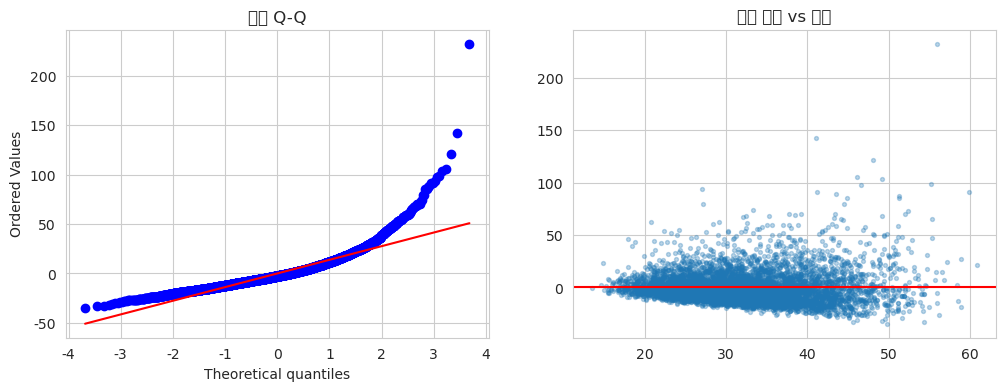

/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


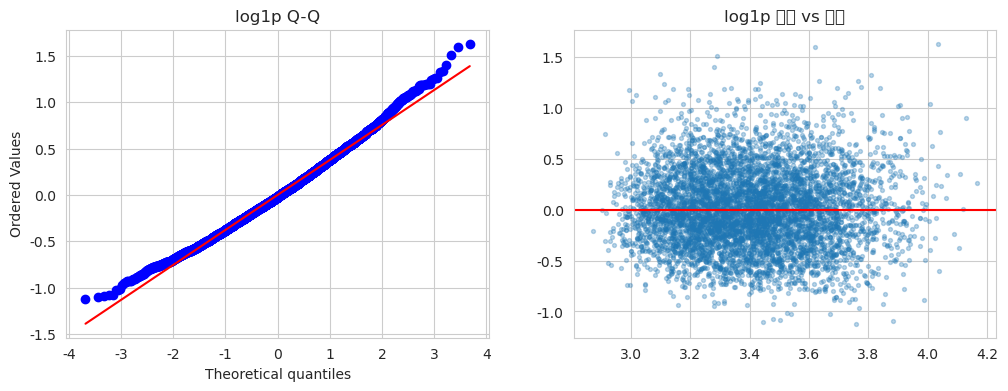

In [23]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.
Q-Q plot의 직선 순응도가 상승하여 잔차의 정규성이 확보되었고, 예측값에 따른 잔차 산점도도 로그변환 이후 균일한 띠 형태로 고르게 분포하여 등분산성이 확보되었다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [24]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        18:36:51   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

쿠폰 미발송 고객에 비해 쿠폰 발송 고객의 반응 오즈가 2.434배 높다. 따라서 쿠폰 발송하는 것은 고객 반응률을 강하게 끌어올린다. 'Basic' 등급 고객과 비교했을 때, 'Silver' 등급 고객은 반응 오즈가 1.407배 높고 'Gold' 등급 고객은 반응 오즈가 2.019배 높다. 따라서 멤버십 등급이 높을수록 혜택에 호응률이 높아진다.
따라서 다음 캠페인 세그먼트는 influencer 채널로 유입된 Gold 등급의 고객으로 정하면 캠페인 반응률을 극대화할 수 있다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)

